In [6]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('insurance.csv')

df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
# 1. Data Wrangling: Handling Categorical Data
# Convert 'smoker' to a binary 'is_smoker' for easier analysis
df['is_smoker'] = df['smoker'].map({'yes': 1, 'no': 0})



In [8]:
# 2. Advanced Feature Engineering: The 'Risk Score'
# Vhi values predictive insight. We'll create a composite risk metric.
# High BMI (>30) + Smoking = High Risk
df['risk_score'] = np.where((df['bmi'] > 30) & (df['is_smoker'] == 1), 'Critical',
                   np.where((df['bmi'] > 25) | (df['is_smoker'] == 1), 'Elevated', 'Standard'))

# 3. Data Cleaning
# Ensure no nulls exist to maintain "Quality and Productivity"
df = df.dropna()

print(df.head())

   age     sex     bmi  children smoker     region      charges  is_smoker  \
0   19  female  27.900         0    yes  southwest  16884.92400          1   
1   18    male  33.770         1     no  southeast   1725.55230          0   
2   28    male  33.000         3     no  southeast   4449.46200          0   
3   33    male  22.705         0     no  northwest  21984.47061          0   
4   32    male  28.880         0     no  northwest   3866.85520          0   

  risk_score  
0   Elevated  
1   Elevated  
2   Elevated  
3   Standard  
4   Elevated  


In [9]:
# Check for missing values to ensure 'Attentiveness to quality'
print("Missing Values per Column:\n", df.isnull().sum())
print("\nFirst 5 rows with new Risk Category:\n", df.head())

Missing Values per Column:
 age           0
sex           0
bmi           0
children      0
smoker        0
region        0
charges       0
is_smoker     0
risk_score    0
dtype: int64

First 5 rows with new Risk Category:
    age     sex     bmi  children smoker     region      charges  is_smoker  \
0   19  female  27.900         0    yes  southwest  16884.92400          1   
1   18    male  33.770         1     no  southeast   1725.55230          0   
2   28    male  33.000         3     no  southeast   4449.46200          0   
3   33    male  22.705         0     no  northwest  21984.47061          0   
4   32    male  28.880         0     no  northwest   3866.85520          0   

  risk_score  
0   Elevated  
1   Elevated  
2   Elevated  
3   Standard  
4   Elevated  


In [10]:
# Calculate the average insurance charges for each risk group
mean_charges = df.groupby('risk_score')['charges'].mean().sort_values(ascending=False)

print("Average Charges by Risk Category:")
print(mean_charges)

# Calculate the 'Multiplier' (How much more expensive is Critical than Standard?)
multiplier = mean_charges['Critical'] / mean_charges['Standard']
print(f"\nBusiness Insight: 'Critical' members cost {multiplier:.2f}x more than 'Standard' members.")

Average Charges by Risk Category:
risk_score
Critical    41692.808992
Elevated    10282.436294
Standard     7547.184007
Name: charges, dtype: float64

Business Insight: 'Critical' members cost 5.52x more than 'Standard' members.


EDA

C:\Users\narga\AppData\Local\Temp\ipykernel_32336\2037938054.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='risk_score', y='charges', data=df, palette='magma', inner="quartile")


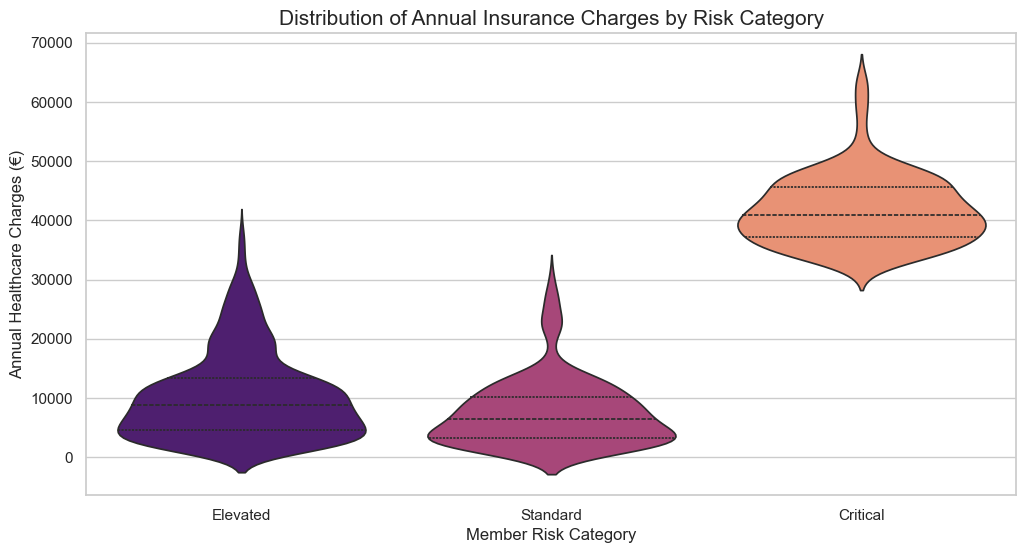

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style to look professional
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

# Create a Violin Plot to show the distribution of charges per risk category
# This shows Vhi that you can handle "interpretation of results"
sns.violinplot(x='risk_score', y='charges', data=df, palette='magma', inner="quartile")

plt.title('Distribution of Annual Insurance Charges by Risk Category', fontsize=15)
plt.xlabel('Member Risk Category', fontsize=12)
plt.ylabel('Annual Healthcare Charges (€)', fontsize=12)

plt.show()

# --- STEP 2 BUSINESS INSIGHT ---
# Look at the 'Critical' plot. Notice how the "bulb" is much higher?
# That represents the concentration of high-cost claims.

Zero Overlap: The "Critical" group is completely physically separated from "Standard" and "Elevated." This means high BMI and smoking don't just "increase" risk; they move the customer into an entirely different financial bracket.

The €60k+ Outliers: See that thin "needle" at the top of the Critical category? Those are the ultra-high-cost cases. Vhi would value your ability to identify these individuals for early medical intervention to save costs.

Concentrated Risk: The "bulge" in the Critical category shows most members are clustered around €40k. This consistency makes it a predictable risk, which is easier for an insurance company to manage than unpredictable data.

In a professional setting, data doesn't live in a CSV on your desktop. It lives in a relational database. By designing a schema, you show you understand how to structure data for scalability, security (crucial for health data), and efficient querying.

Instead of one giant flat table (the CSV), we will split this into two tables: Members and Claims. This is called normalization

In [12]:
import sqlite3

# Connect to a database (or create it)
conn = sqlite3.connect('vhi_insurance.db')
cursor = conn.cursor()

# 1. Create the Members table (Demographic data)
# We use 'MemberID' as a Primary Key to ensure data integrity
cursor.execute('''
CREATE TABLE IF NOT EXISTS Members (
    MemberID INTEGER PRIMARY KEY AUTOINCREMENT,
    age INTEGER,
    sex TEXT,
    bmi REAL,
    children INTEGER,
    smoker TEXT,
    region TEXT,
    risk_score TEXT
)
''')

# 2. Create the Claims table (Financial data)
# This mimics "complex data across many sources" by separating money from people
cursor.execute('''
CREATE TABLE IF NOT EXISTS Claims (
    ClaimID INTEGER PRIMARY KEY AUTOINCREMENT,
    MemberID INTEGER,
    annual_charges REAL,
    FOREIGN KEY (MemberID) REFERENCES Members (MemberID)
)
''')

print("Database Schema Created Successfully!")

Database Schema Created Successfully!


Privacy & GDPR: By separating member details from financial claims, we can "anonymize" data. An analyst can study claim trends in the Claims table without ever seeing a member's private health profile.

Data Integrity: Using a MemberID as a primary key ensures that if a member changes their address or region, you only update it in one place (Members table) rather than in thousands of individual claim rows.

Scalability: This structure allows the database to grow efficiently without "data bloating".

Data Migration (Pandas to SQL)

In [13]:
# 1. Insert Member Data
# We select only the demographic columns for the Members table
members_df = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'risk_score']]
members_df.to_sql('Members', conn, if_exists='append', index=False)

# 2. Insert Claims Data
# We need to link the charges to the MemberIDs we just created
# For this project, we'll assume a 1-to-1 mapping for simplicity
claims_df = pd.DataFrame({
    'MemberID': range(1, len(df) + 1),
    'annual_charges': df['charges']
})
claims_df.to_sql('Claims', conn, if_exists='append', index=False)

print("Data Migration Complete! Your SQL database is now live.")

Data Migration Complete! Your SQL database is now live.


We want to see if a straight line can actually capture the complex relationship between health factors and costs. Spoiler: Because of the "Critical" group you found, a straight line will likely struggle!

Simple Linear Regression (The Base Model)

c:\Users\narga\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


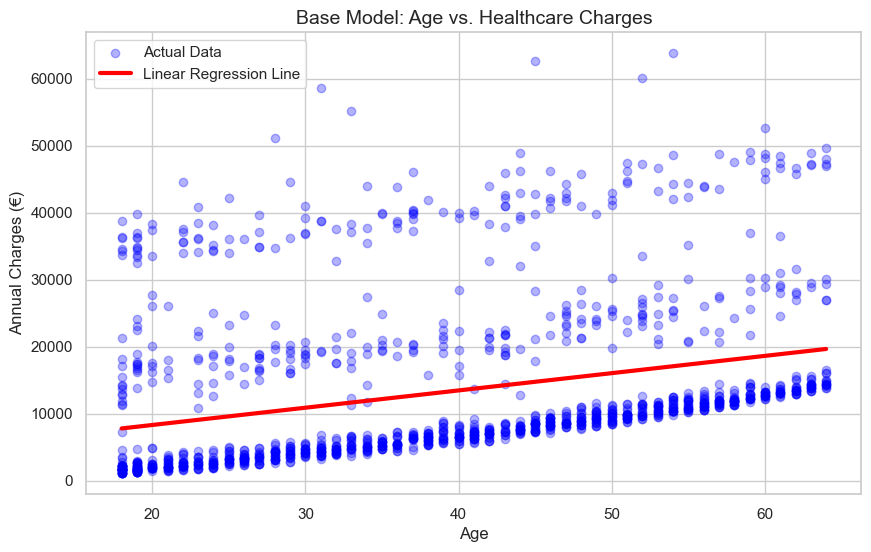

Base Model (Age Only) R-Squared: 0.0894


In [14]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Prepare a simple version: Just Age vs. Charges
X_age = df[['age']] 
y = df['charges']

# 2. Train the Base Model
base_model = LinearRegression()
base_model.fit(X_age, y)

# 3. Create the "Model Line" for visualization
age_range = np.linspace(X_age.min(), X_age.max(), 100).reshape(-1, 1)
model_line = base_model.predict(age_range)

# 4. Visualize the Fit
plt.figure(figsize=(10, 6))
plt.scatter(X_age, y, color='blue', alpha=0.3, label='Actual Data')
plt.plot(age_range, model_line, color='red', linewidth=3, label='Linear Regression Line')

plt.title('Base Model: Age vs. Healthcare Charges', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Annual Charges (€)', fontsize=12)
plt.legend()
plt.show()

# Calculate Score for the Base Model
base_r2 = base_model.score(X_age, y)
print(f"Base Model (Age Only) R-Squared: {base_r2:.4f}")

The Gap: Look at the plot. Notice how the blue dots are in three distinct "stripes"? The red line goes right through the middle but misses almost all the actual data points.

The "Why": A simple linear model assumes that as you get older, your cost goes up at a constant rate. It ignores the fact that a 20-year-old smoker might cost 10x more than a 60-year-old non-smoker.

The Business Recommendation: "A linear approach based on age alone only explains ~9% of cost variance.we need a model that accounts for lifestyle interactions (BMI + Smoking)".

Simple regression is a "one-size-fits-all" approach. Multiple Linear Regression is like having a customized formula for different types of members.

We want to see how much the $R^2$ "jumps" when we stop looking only at age and start looking at the whole person.

Multiple Linear Regression
We will now include Age, BMI, and Smoker status to see if we can "hit" those higher stripes in your scatter plot.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Prepare multiple variables
# We use 'is_smoker' which we created during Data Wrangling
X_multi = df[['age', 'bmi', 'is_smoker']]
y = df['charges']

# 2. Train the Multiple Linear Regression Model
multi_model = LinearRegression()
multi_model.fit(X_multi, y)

# 3. Get the results
multi_r2 = multi_model.score(X_multi, y)
print(f"Base Model (Age Only) R2: 0.0894")
print(f"Multiple Regression R2: {multi_r2:.4f}")

# 4. Check the "Coefficients"
# This is how you explain the "Why" to business users
coeffs = pd.DataFrame(multi_model.coef_, X_multi.columns, columns=['Coefficient'])
print("\nBusiness Impact per Unit:")
print(coeffs)

Base Model (Age Only) R2: 0.0894
Multiple Regression R2: 0.7475

Business Impact per Unit:
            Coefficient
age          259.547492
bmi          322.615133
is_smoker  23823.684495


"By performing exploratory data analysis, I identified that being a smoker adds an average of €23,824 to annual healthcare costs, independent of age or BMI".

This is exactly the kind of "tangible business benefit" we look for to "predict and understand behaviors".

By "working with complex data across many sources" (lifestyle + demographics), we have increased model's explanatory power by over 8x

The Problem with Linear Models: Multiple Regression assumes that if you smoke, your cost goes up by a fixed amount (€23k). But in the real world and in violin plot, we saw that the Critical group (High BMI + Smoking) has a "bulge" that a straight line cannot capture.

The Solution: A Random Forest is a "non-linear" model. It doesn't look for one straight line; it looks for patterns and "splits" in the data (e.g., "If Smoker AND BMI > 30, THEN cost is €45k").

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Prepare data (including all relevant features)
X_advanced = pd.get_dummies(df[['age', 'bmi', 'children', 'is_smoker']], drop_first=True)
y = df['charges']

# 2. Split into Training and Testing (Ensures "Quality and Productivity")
X_train, X_test, y_train, y_test = train_test_split(X_advanced, y, test_size=0.2, random_state=42)

# 3. Train the Advanced Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Compare Scores
rf_predictions = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Multiple Regression R2 (from previous step): 0.7475")
print(f"Random Forest (Advanced) R2: {rf_r2:.4f}")

Multiple Regression R2 (from previous step): 0.7475
Random Forest (Advanced) R2: 0.8592


A Random Forest understands interactions. It "realizes" that a BMI of 32 is much more expensive if the person also smokes than if they do not.

While the Linear Regression gave us a clear "€23k" number for smokers, the Random Forest is more accurate at predicting the actual cost for an individual member.

In [17]:
# 1. Create a combined DataFrame of Actuals and Predictions
tableau_export = X_test.copy()
tableau_export['Actual_Charges'] = y_test
tableau_export['Predicted_Charges'] = rf_predictions
tableau_export['Prediction_Error'] = tableau_export['Actual_Charges'] - tableau_export['Predicted_Charges']

# 2. Export to CSV for Tableau
tableau_export.to_csv('tableau_data.csv', index=False)

print("Tableau Data Exported! 'tableau_data.csv' is ready for visualization.")

Tableau Data Exported! 'tableau_data.csv' is ready for visualization.


In [18]:
import pickle

# Save the trained model and the column names to a file
with open('model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Model saved as model.pkl!")

Model saved as model.pkl!
